# Load a TIB-AV-A Project File

In [94]:
import io

colab = False
try:
    from google.colab import files
    colab = True
    uploaded = files.upload()
    zip_buffer = io.BytesIO(list(uploaded.values())[0])
except ImportError:
    import ipywidgets as widgets
    from IPython.display import display
    
    upload = widgets.FileUpload(multiple=False)

    display(upload)


FileUpload(value=(), description='Upload')

In [138]:
if not colab:
    uploaded_file = upload.value[0]
    content = uploaded_file['content']
    zip_buffer = io.BytesIO(content)

# Take a Look at the File 

In [139]:
import zipfile
import yaml
import json
import data as tibava_data

data_manager = tibava_data.DataManager()

with zipfile.ZipFile(zip_buffer, "r") as zip_file:
    for name in zip_file.namelist():
        if name.startswith("data/") and name.endswith(".zip"):
            with zip_file.open(name) as f:
                with data_manager.load_from_io(f) as data:
                    print(data.type, data.id)
                

ImagesData 71dc9da7704e42e5bd717e0728f1ab22
ShotsData 07afa53a43dc428facb18be558e6ed14
ScalarData a071ac35fbbe42e49c20e2780ba55b07
ScalarData 998d99cba8f84c638494096e7a871e6c
ScalarData 05c17d2ccc364adebfa95ec6cf9cafee
ScalarData 1023eff140144cddb0807b978d84d1e6
ScalarData afb3b3539ff94e2b8c0c4029f24e93e6
ScalarData 6340741cc1b84aaa992645cb75016d63
ScalarData 84c75e0e55014d6a9b71eae5e89707ad
ScalarData a8f2dea5545544bf82aec1de2fa232a4
ScalarData 562d808aa73b4afcbaf78c27a4952bba
ScalarData b535f8fa78d34817adfc7d919666ebed
ScalarData 72ed19fe666949ab847bc1e67d7dd2fd
ScalarData 5b727b3dea124330a6a408651b1d855c
ClusterData 321f0c1efb5041129a2c81726421cbe7
FacesData d00e31e0002b4a3daf54279f2ea7aa51
BboxesData 1a16a21204544e8ea0794c940a4de9ab
KpssData 3007c356de1947f9ad90da68e386e6b9
ImagesData 51cac8c0606e4adca0a923f49a4cd817
ImageEmbeddings 10a3ddffabfa442092358cd2da1a78e5
ScalarData 0e6e119cd1f1449794940d95fb097002
AnnotationData 70770b0f560848018bf3dd6d155918e3
AnnotationData aece1f4b9ae

# Read Shot Size Information

In [140]:
shot_annotations = []
shot_start_end = []

def data_iterator(zip_buffer):
    with zipfile.ZipFile(zip_buffer, "r") as zip_file:
        for name in zip_file.namelist():
            if name.startswith("data/") and name.endswith(".zip"):
                with zip_file.open(name) as f:
                    with data_manager.load_from_io(f) as data:
                        yield data

for data in data_iterator(zip_buffer):
    
    shot_annotations = []
    shot_start_end = []
    #if data.type == "FacesData":
    #    print(data)
    if data.type == "AnnotationData":
        for x in data.annotations:
            for label in x.labels:
                if "Shot Size::" in label:
                    shot_annotations.append(label.split("Shot Size::")[-1])
                    shot_start_end.append([x.start, x.end])

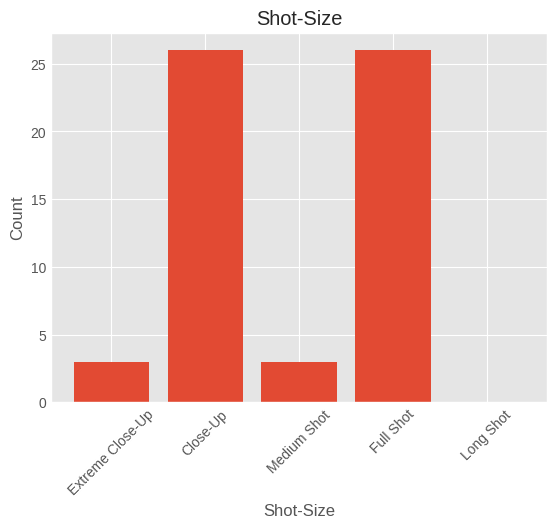

In [141]:
import matplotlib.pyplot as plt
# plt.style.use("seaborn-v0_8-whitegrid")
plt.style.use("ggplot")

labels = ["Extreme Close-Up", "Close-Up", "Medium Shot", "Full Shot", "Long Shot"]
values = [0 for x in labels]

for x in shot_annotations:
    label_index = labels.index(x)
    values[label_index]+=1     
    
plt.bar(labels, values)
plt.xlabel("Shot-Size")
plt.ylabel("Count")
plt.title("Shot-Size")
plt.xticks(rotation=45)
plt.show()

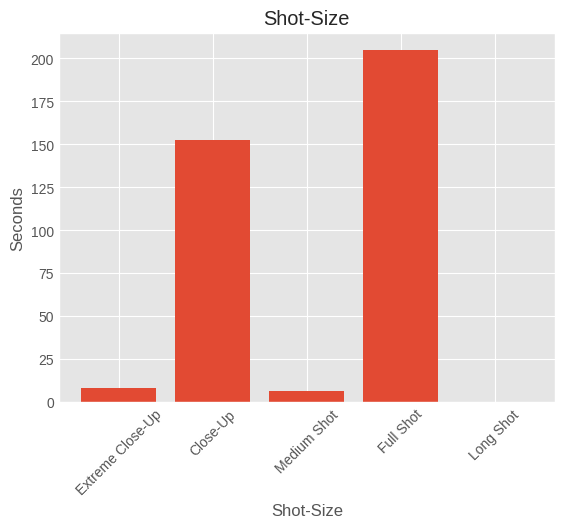

In [142]:
import matplotlib.pyplot as plt

labels = ["Extreme Close-Up", "Close-Up", "Medium Shot", "Full Shot", "Long Shot"]
values = [0.0 for x in labels]

for x in shot_annotations:
    label_index = labels.index(x)
    values[label_index]+=shot_start_end[label_index][1] - shot_start_end[label_index][0]   
    
plt.bar(labels, values)
plt.xlabel("Shot-Size")
plt.ylabel("Seconds")
plt.title("Shot-Size")
plt.xticks(rotation=45)
plt.show()

# Read Face Clustering Data Information

In [143]:
faces = {}
for data in data_iterator(zip_buffer):
    if data.type == "FacesData":
        for face in data.faces:
            faces[face.id]={}
            
embeddings_map = {}
for data in data_iterator(zip_buffer):
    if data.type == "ImageEmbeddings":
        for emb in data.embeddings:
            embeddings_map[emb.id] = emb.ref_id
            faces[emb.ref_id]["time"] = emb.time
    if data.type == "BboxesData":
        for bbox in data.bboxes:
            faces[bbox.ref_id]["bbox"] = bbox.to_dict()

for data in data_iterator(zip_buffer):
    if data.type == "ClusterData":
        for i, cluster in enumerate(data.clusters):
            for id in cluster.embedding_ids:
                faces[embeddings_map[id]]["cluster"] = i

print(list(faces.items())[0])


('2c321081b2bc49a7875cd6cc25801cf0', {'bbox': {'id': 'e6332bbb7d194467893a9b02db923564', 'version': '1.0', 'type': 'PluginData', 'name': None, 'ref_id': '2c321081b2bc49a7875cd6cc25801cf0', 'x': 0.14427083333333332, 'y': 0.15555555555555556, 'w': 0.16197916666666667, 'h': 0.4777777777777778, 'det_score': 0.80029296875, 'time': 3.0, 'delta_time': 0.5, 'image_id': None}, 'time': 3.0, 'cluster': 0})


In [144]:
# init the result entry
shot_face_count = {
    "Extreme Close-Up":[0,0,0], 
    "Close-Up":[0,0,0], 
    "Medium Shot":[0,0,0], 
    "Full Shot":[0,0,0], 
    "Long Shot":[0,0,0]
}

for index, [shot_start, shot_end] in enumerate(shot_start_end):
    shot_faces = set()
    for face in faces.values():
        if shot_start<face["time"] and face["time"] < shot_end:
            shot_faces.add(face["cluster"])
    
    anno = shot_annotations[index]

    # distinction based on the number of faces
    if len(shot_faces) == 1:
        shot_face_count[anno][0] +=1
    if len(shot_faces) == 2:
        shot_face_count[anno][1] +=1
    if len(shot_faces) > 2:
        shot_face_count[anno][2] +=1
    
        

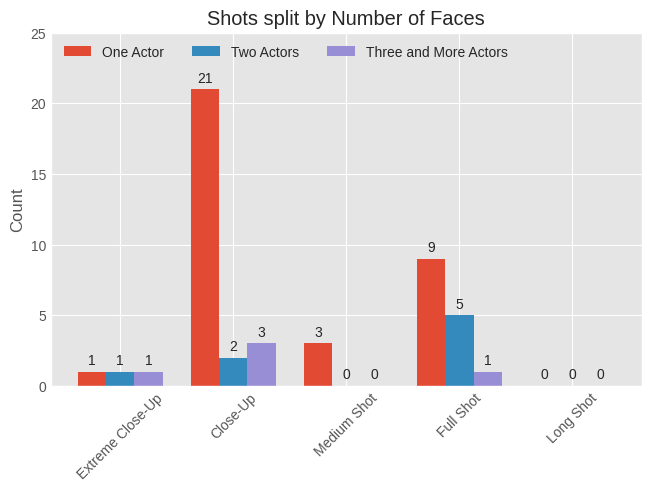

In [145]:
import numpy as np

x = np.arange(len(shot_face_count))  # the label locations
width = 0.25  # the width of the bars
multiplier = 0

fig, ax = plt.subplots(layout='constrained')

for num_faces, label in enumerate(["One Actor", "Two Actors", "Three and More Actors"]):
    offset = width * multiplier
    rects = ax.bar(x + offset, [x[num_faces] for x in shot_face_count.values()], width, label=label)
    ax.bar_label(rects, padding=3)
    multiplier += 1

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('Count')
ax.set_title('Shots split by Number of Faces')
ax.set_xticks(x + width, shot_face_count.keys())
ax.legend(loc='upper left', ncols=3)

plt.xticks(rotation=45)
ax.set_ylim(0, 25)

plt.show()

# Shot Reverse Shot Detection

In [146]:

shot_face_list = []

for index, [shot_start, shot_end] in enumerate(shot_start_end):
    shot_faces = set()
    for face in faces.values():
        if shot_start<face["time"] and face["time"] < shot_end:
            shot_faces.add(face["cluster"])

    shot_face_list.append(list(shot_faces))

def detect_shot_reverse_shot(shots, min_length=4):
    results = []
    n = len(shots)
    i = 0

    while i < n - 2:

        # Check first two shots are single-person and different
        if len(shots[i]) == 1 and len(shots[i+1]) == 1:
            A = shots[i][0]
            B = shots[i+1][0]

            if A != B:

                start = i
                expected = A
                j = i

                # Follow alternating pattern
                while j < n and len(shots[j]) == 1:
                    current = shots[j][0]

                    if current != expected:
                        break

                    # Switch expected speaker
                    expected = B if expected == A else A
                    j += 1

                length = j - start

                if length >= min_length:
                    results.append((start, j-1, (A, B)))
                    i = j  # skip past this block
                    continue

        i += 1

    return results
    
# get all shot_reverse_shot results
srs_list = detect_shot_reverse_shot(shot_face_list)


[(9, 15, (0, 1)), (46, 49, (2, 0)), (53, 57, (0, 1))]


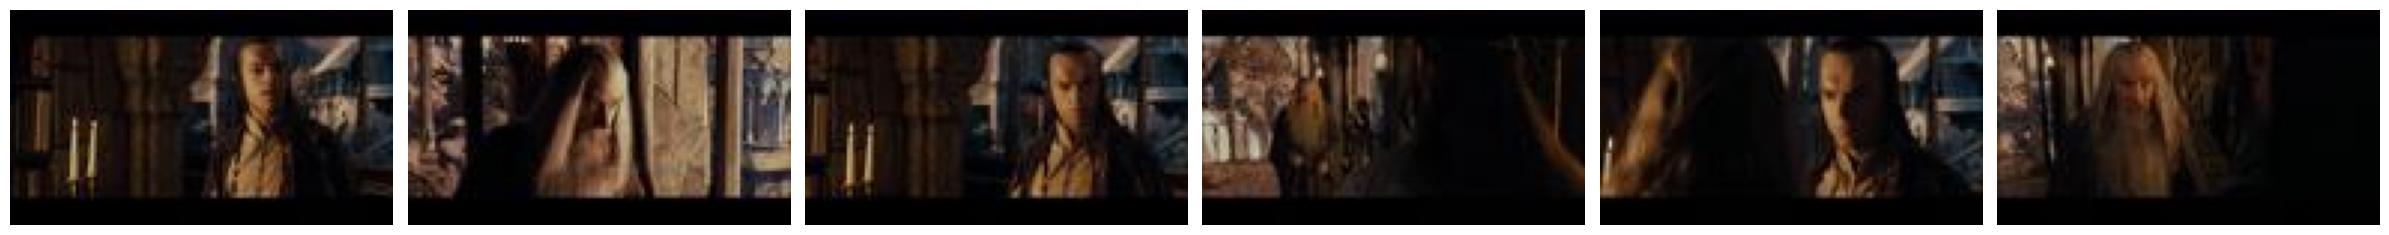

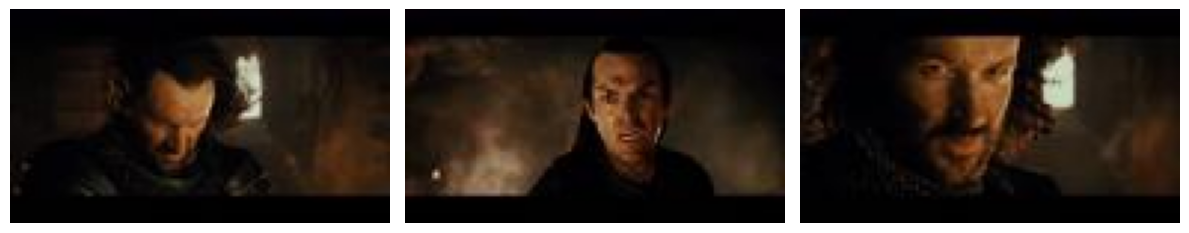

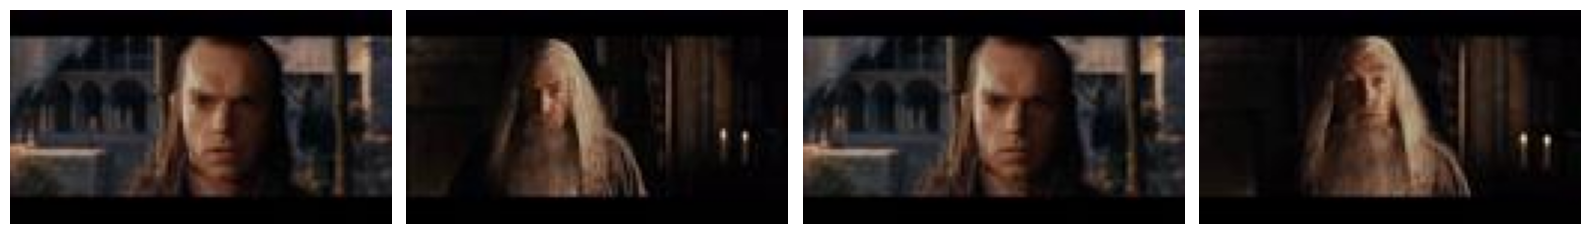

In [149]:
time_image_list = []

for data in data_iterator(zip_buffer):
    if data.type == "ImagesData":
        for image in data.images:
            # skip face images
            if image.ref_id is not None:
                continue
                
            img = data.load_image(image)
            time_image_list.append([image.time, img])

# show these shots

def show_shot_sequences(shot_list,time_image_list):

    def show_images(images):
        n = len(images)
        fig, axes = plt.subplots(1, n, figsize=(4*n, 4))
    
        if n == 1:
            axes = [axes]
    
        for ax, img in zip(axes, images):
            ax.imshow(img)
            ax.axis("off")
    
        plt.tight_layout()
        plt.show()
        
    for shot in shot_list:
        images_list = []
        for shot_index in range(shot[0], shot[1]):
            start = shot_start_end[shot_index][0]
            end = shot_start_end[shot_index][1]
            for image in time_image_list:
                if start < image[0] and image[0] < end:
                    images_list.append(image[1])
                    break
    
        show_images(images_list)
show_shot_sequences(srs_list, time_image_list)

# Opposition

In [135]:
# Some helper functions
def iou_xywh(box1, box2):
    x1, y1, w1, h1 = box1
    x2, y2, w2, h2 = box2

    # Convert to (x1, y1, x2, y2)
    x1_max = x1 + w1
    y1_max = y1 + h1

    x2_max = x2 + w2
    y2_max = y2 + h2

    # Intersection rectangle
    inter_x1 = max(x1, x2)
    inter_y1 = max(y1, y2)
    inter_x2 = min(x1_max, x2_max)
    inter_y2 = min(y1_max, y2_max)

    # Compute intersection area
    inter_width = max(0, inter_x2 - inter_x1)
    inter_height = max(0, inter_y2 - inter_y1)
    inter_area = inter_width * inter_height

    # Areas of boxes
    area1 = w1 * h1
    area2 = w2 * h2

    # Union
    union_area = area1 + area2 - inter_area

    if union_area == 0:
        return 0

    return inter_area / union_area

def left_right_cls(bbox):
    l_iou = iou_xywh([bbox["x"], bbox["y"], bbox["w"], bbox["h"]],[0,0,0.5,1.0])
    r_iou = iou_xywh([bbox["x"], bbox["y"], bbox["w"], bbox["h"]],[0.5,0,0.5,1.0])
    return l_iou, r_iou


In [157]:

shot_face_left_right_list = []
for index, [shot_start, shot_end] in enumerate(shot_start_end):
    shot_faces = set()
    shot_left_right = {}
    for face in faces.values():
        if shot_start<face["time"] and face["time"] < shot_end:
            l_r = left_right_cls(face["bbox"])
            shot_faces.add(face["cluster"])
            
            if face["cluster"] not in shot_left_right:
                shot_left_right[face["cluster"]] = [0.0,0.0]
            shot_left_right[face["cluster"]][0]+= l_r[0]
            shot_left_right[face["cluster"]][1]+= l_r[1]

    shot_results = []
    for shot_face in shot_faces:
        shot_results.append({
            "cluster": shot_face,
            "lr":  "left" if shot_left_right[shot_face][0]>shot_left_right[shot_face][1] else "right"
        })
    
    shot_face_left_right_list.append(shot_results)


def detect_shot_reverse_shot_opposition(shots, min_length=4):
    results = []
    n = len(shots)
    i = 0

    print(n)

    while i < n - 2:

        # Check first two shots are single-person and different
        print(shots[i])
        if len(shots[i]) == 1 and len(shots[i+1]) == 1:
            
            A = shots[i][0]["cluster"]
            B = shots[i+1][0]["cluster"]
            
            A_lr = shots[i][0]["lr"]
            B_lr = shots[i+1][0]["lr"]
            if A != B and A_lr != B_lr:

                start = i
                expected = A
                expected_lr = A_lr
                j = i

                # Follow alternating pattern
                while j < n and len(shots[j]) == 1:
                    current = shots[j][0]["cluster"]
                    current_lr = shots[j][0]["lr"]

                    if current != expected or current_lr != expected_lr:
                        break

                    # Switch expected speaker
                    expected = B if expected == A else A
                    expected_lr = B_lr if expected_lr == A_lr else A_lr
                    j += 1

                length = j - start

                if length >= min_length:
                    results.append((start, j-1, (A, B)))
                    i = j  # skip past this block
                    continue

        i += 1

    return results
    
# get all shot_reverse_shot results
srso_list = detect_shot_reverse_shot_opposition(shot_face_left_right_list)

58
[]
[{'cluster': 0, 'lr': 'left'}, {'cluster': 1, 'lr': 'right'}]
[{'cluster': 0, 'lr': 'left'}, {'cluster': 1, 'lr': 'right'}, {'cluster': 9, 'lr': 'right'}, {'cluster': 10, 'lr': 'right'}, {'cluster': 11, 'lr': 'left'}]
[{'cluster': 0, 'lr': 'left'}]
[{'cluster': 1, 'lr': 'left'}]
[{'cluster': 0, 'lr': 'right'}]
[]
[{'cluster': 0, 'lr': 'right'}]
[{'cluster': 1, 'lr': 'left'}, {'cluster': 12, 'lr': 'left'}]
[{'cluster': 0, 'lr': 'right'}]
[{'cluster': 1, 'lr': 'left'}, {'cluster': 13, 'lr': 'left'}]
[{'cluster': 0, 'lr': 'right'}]
[{'cluster': 1, 'lr': 'right'}]
[{'cluster': 14, 'lr': 'left'}, {'cluster': 15, 'lr': 'left'}]
[{'cluster': 1, 'lr': 'left'}]
[]
[{'cluster': 4, 'lr': 'right'}, {'cluster': 6, 'lr': 'left'}, {'cluster': 7, 'lr': 'left'}, {'cluster': 16, 'lr': 'left'}, {'cluster': 17, 'lr': 'left'}, {'cluster': 18, 'lr': 'left'}]
[{'cluster': 3, 'lr': 'right'}, {'cluster': 19, 'lr': 'left'}, {'cluster': 20, 'lr': 'left'}]
[{'cluster': 1, 'lr': 'left'}]
[{'cluster': 0, 'lr'

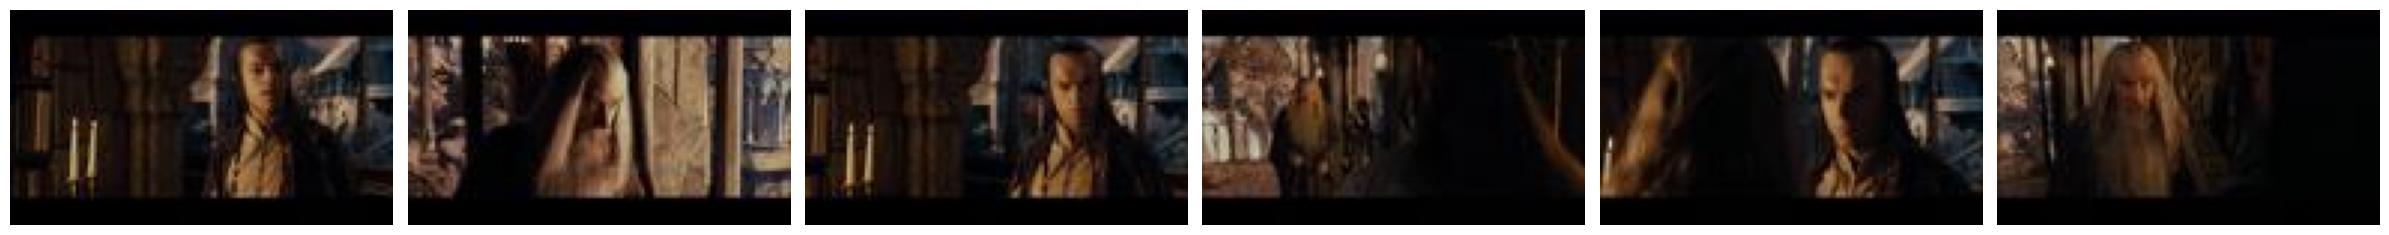

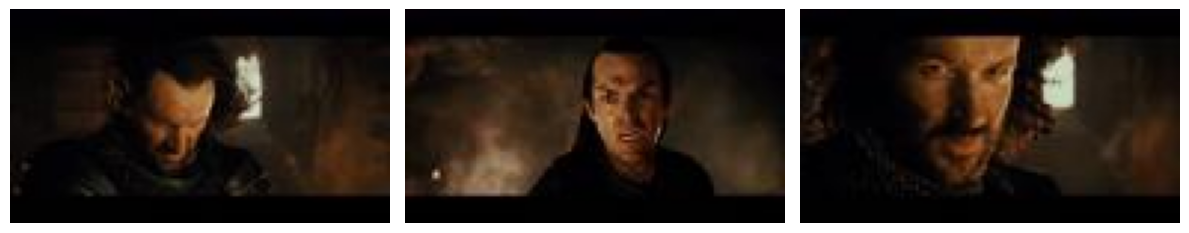

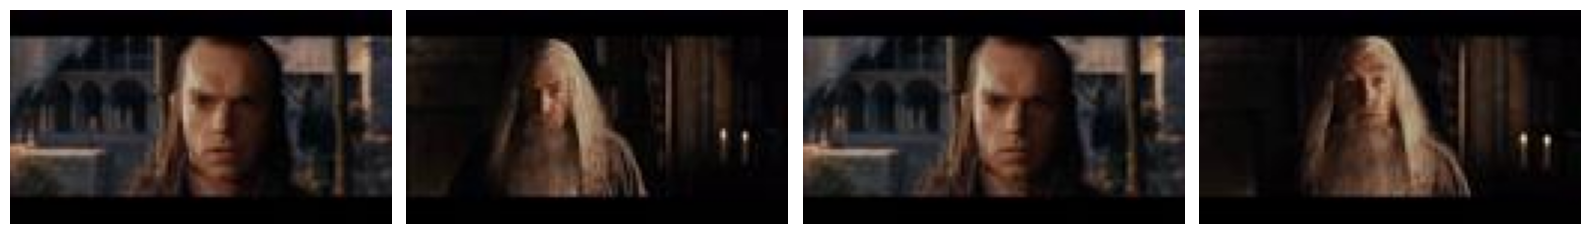

In [158]:
show_shot_sequences(srso_list, time_image_list)